# 🌲 Entrenamiento de Proactive Forest para Detección de Intrusiones en Red (NSL-KDD)

## Descripción del Notebook

Este notebook implementa un entrenamiento **clásico de Machine Learning** (sin aprendizaje federado) utilizando el algoritmo **Proactive Forest** sobre el dataset **NSL-KDD** para detección de intrusiones en redes.

### Objetivos:
1. Cargar y preprocesar el dataset NSL-KDD
2. Entrenar un modelo Proactive Forest
3. Evaluar el modelo mediante métricas de clasificación:
   - Matriz de Confusión
   - Accuracy (Precisión Global)
   - F1-Score (Macro y por clase)
   - Precision (Precisión por clase)
   - Recall (Sensibilidad por clase)

### Dataset
**Fuente:** `../../../data/NSL-KDD_train.csv` (entrenamiento) y `../../../data/NSL-KDD_test.csv` (prueba)  
**Variable objetivo:** `class` (normal, anomaly)

### Características del Dataset:
- **41 features** que describen conexiones de red
- **Clasificación binaria**: normal vs anomaly (intrusión)
- Ya dividido en conjuntos de train y test

---

## 📦 1. Importación de Librerías

In [1]:
# ============================================================================
# LIBRERÍAS PARA MANIPULACIÓN DE DATOS
# ============================================================================
import pandas as pd
import numpy as np

# ============================================================================
# LIBRERÍAS PARA VISUALIZACIÓN
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# LIBRERÍAS PARA PREPROCESAMIENTO Y MÉTRICAS
# ============================================================================
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================================
# MÓDULOS PERSONALIZADOS - PROACTIVE FOREST
# ============================================================================
import sys
sys.path.append('../../../')

from src.infrastructure.dataset.dataset_factory import DatasetFactory

from src.domain.model.proactive_forest import ProactiveForest
from src.domain.metrics.forest_evaluator import ForestEvaluator

# ============================================================================
# CONFIGURACIÓN DE VISUALIZACIÓN
# ============================================================================
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Ignorar warnings para una salida más limpia
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## 📊 2. Carga y Exploración del Dataset

El dataset NSL-KDD ya viene dividido en train y test. Cargamos ambos conjuntos.

In [2]:
# ============================================================================
# CARGA DEL DATASET DE ENTRENAMIENTO
# ============================================================================
print("=" * 80)
print("📊 CARGA DEL DATASET NSL-KDD")
print("=" * 80)

df_train = pd.read_csv(
    '../../../data/NSL-KDD_train.csv',
    encoding='utf-8'
)

print(f"✅ Dataset de entrenamiento cargado exitosamente")
print(f"📊 Dimensiones (train): {df_train.shape[0]} filas × {df_train.shape[1]} columnas")

# Cargar dataset de prueba
df_test = pd.read_csv(
    '../../../data/NSL-KDD_test.csv',
    encoding='utf-8'
)

print(f"✅ Dataset de prueba cargado exitosamente")
print(f"📊 Dimensiones (test): {df_test.shape[0]} filas × {df_test.shape[1]} columnas")

📊 CARGA DEL DATASET NSL-KDD
✅ Dataset de entrenamiento cargado exitosamente
📊 Dimensiones (train): 151165 filas × 42 columnas
✅ Dataset de prueba cargado exitosamente
📊 Dimensiones (test): 34394 filas × 42 columnas


In [3]:
# ============================================================================
# VISUALIZACIÓN DE LAS PRIMERAS FILAS
# ============================================================================
print("\n📋 Primeras 5 filas del dataset de entrenamiento:")
df_train.head()


📋 Primeras 5 filas del dataset de entrenamiento:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
# ============================================================================
# INFORMACIÓN GENERAL DEL DATASET
# ============================================================================
print("=" * 80)
print("📝 INFORMACIÓN DEL DATASET DE ENTRENAMIENTO")
print("=" * 80)
df_train.info()

📝 INFORMACIÓN DEL DATASET DE ENTRENAMIENTO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151165 entries, 0 to 151164
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     151165 non-null  int64  
 1   protocol_type                151165 non-null  object 
 2   service                      151165 non-null  object 
 3   flag                         151165 non-null  object 
 4   src_bytes                    151165 non-null  int64  
 5   dst_bytes                    151165 non-null  int64  
 6   land                         151165 non-null  int64  
 7   wrong_fragment               151165 non-null  int64  
 8   urgent                       151165 non-null  int64  
 9   hot                          151165 non-null  int64  
 10  num_failed_logins            151165 non-null  int64  
 11  logged_in                    151165 non-null  int64  
 12  num_compromised

In [5]:
# ============================================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================
print("=" * 80)
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 80)
df_train.describe()

📈 ESTADÍSTICAS DESCRIPTIVAS


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,151165.000000,1.511650e+05,1.511650e+05,151165.000000,151165.000000,151165.000000,151165.000000,151165.000000,151165.000000,151165.000000,...,151165.000000,151165.000000,151165.000000,151165.000000,151165.000000,151165.000000,151165.000000,151165.000000,151165.000000,151165.000000
mean,290.129302,4.202769e+04,1.706480e+04,0.000179,0.022862,0.000099,0.203347,0.001217,0.395574,0.270684,...,182.212794,115.554685,0.521000,0.082882,0.148225,0.032426,0.284677,0.278711,0.118660,0.119995
std,2618.365506,5.448522e+06,3.671113e+06,0.013363,0.254657,0.013364,2.150669,0.045269,0.488975,22.266054,...,99.170637,110.693281,0.448947,0.188634,0.308891,0.112235,0.444872,0.445736,0.306442,0.319106
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,62.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.760000e+02,5.200000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# ============================================================================
# VERIFICACIÓN DE VALORES NULOS
# ============================================================================
print("🔍 Valores nulos en entrenamiento:")
null_counts_train = df_train.isnull().sum()
null_counts_train[null_counts_train > 0] if null_counts_train.sum() > 0 else print("✅ No hay valores nulos en el dataset de entrenamiento")

print("\n🔍 Valores nulos en prueba:")
null_counts_test = df_test.isnull().sum()
null_counts_test[null_counts_test > 0] if null_counts_test.sum() > 0 else print("✅ No hay valores nulos en el dataset de prueba")

🔍 Valores nulos en entrenamiento:
✅ No hay valores nulos en el dataset de entrenamiento

🔍 Valores nulos en prueba:
✅ No hay valores nulos en el dataset de prueba


## 🎯 3. Análisis de la Variable Objetivo

La variable `class` indica si una conexión es normal o una anomalía/intrusión:
- **normal**: Conexión de red normal
- **anomaly**: Conexión anómala o intrusión

🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (class) - ENTRENAMIENTO
         Cantidad  Porcentaje (%)
class                            
normal      80792       53.446234
anomaly     70373       46.553766


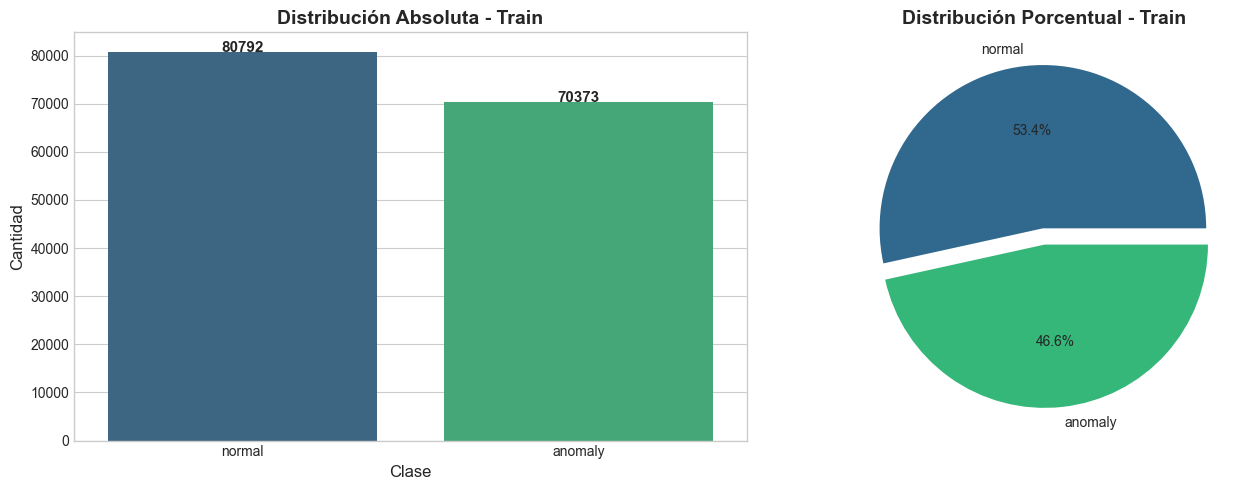

In [7]:
# ============================================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (ENTRENAMIENTO)
# ============================================================================
print("=" * 80)
print("🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (class) - ENTRENAMIENTO")
print("=" * 80)
target_counts_train = df_train['class'].value_counts()
target_pct_train = df_train['class'].value_counts(normalize=True) * 100

distribution_df_train = pd.DataFrame({
    'Cantidad': target_counts_train,
    'Porcentaje (%)': target_pct_train
})
print(distribution_df_train)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=target_counts_train.index,
    y=target_counts_train.values,
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('Distribución Absoluta - Train', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)
for i, v in enumerate(target_counts_train.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')

axes[1].pie(
    target_counts_train.values,
    labels=target_counts_train.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(target_counts_train)),
    explode=[0.05] * len(target_counts_train)
)
axes[1].set_title('Distribución Porcentual - Train', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (class) - PRUEBA
         Cantidad  Porcentaje (%)
class                            
anomaly     22531       65.508519
normal      11863       34.491481


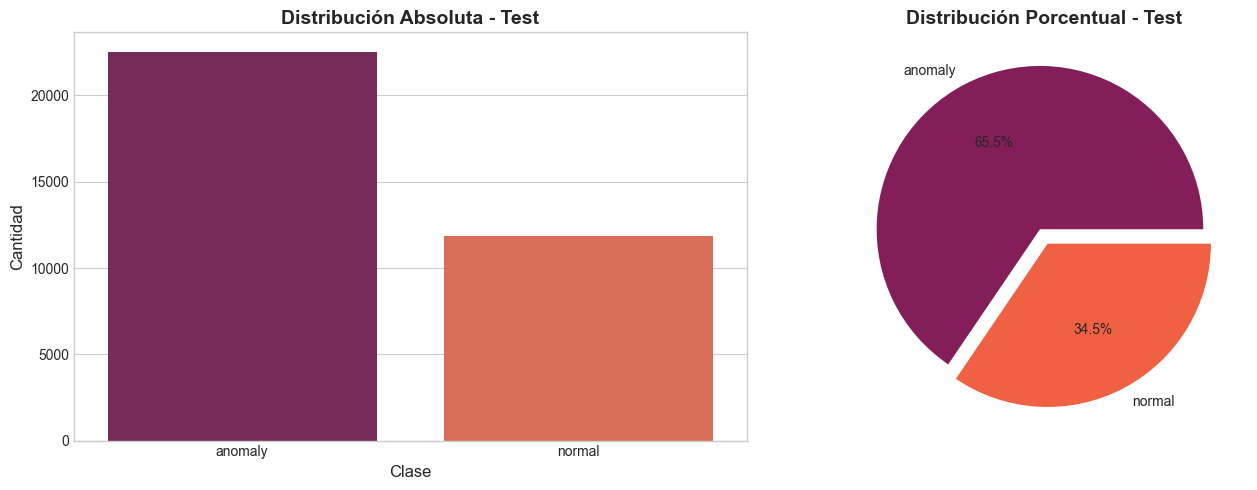

In [8]:
# ============================================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (PRUEBA)
# ============================================================================
print("=" * 80)
print("🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (class) - PRUEBA")
print("=" * 80)
target_counts_test = df_test['class'].value_counts()
target_pct_test = df_test['class'].value_counts(normalize=True) * 100

distribution_df_test = pd.DataFrame({
    'Cantidad': target_counts_test,
    'Porcentaje (%)': target_pct_test
})
print(distribution_df_test)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=target_counts_test.index,
    y=target_counts_test.values,
    ax=axes[0],
    palette='rocket'
)
axes[0].set_title('Distribución Absoluta - Test', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)

axes[1].pie(
    target_counts_test.values,
    labels=target_counts_test.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('rocket', len(target_counts_test)),
    explode=[0.05] * len(target_counts_test)
)
axes[1].set_title('Distribución Porcentual - Test', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 🔧 4. Preprocesamiento de Datos

### Pasos de Preprocesamiento:
1. **Codificación de variables categóricas**: `protocol_type`, `service`, `flag`
2. **Codificación de la variable objetivo**: Convertir 'normal' y 'anomaly' a valores numéricos
3. **Separación de features y target**

In [9]:
# ============================================================================
# PREPROCESAMIENTO - CODIFICACIÓN DE VARIABLES
# ============================================================================
print("=" * 80)
print("🔧 PREPROCESAMIENTO DE DATOS")
print("=" * 80)

# Identificar columnas categóricas
categorical_cols = ['protocol_type', 'service', 'flag']
print(f"\n📋 Columnas categóricas a codificar: {categorical_cols}")

# Crear copias de los dataframes
df_train_processed = df_train.copy()
df_test_processed = df_test.copy()

# Codificar variables categóricas con Label Encoding
for col in categorical_cols:
    le = LabelEncoder()
    df_train_processed[col] = le.fit_transform(df_train_processed[col].astype(str))
    df_test_processed[col] = le.transform(df_test_processed[col].astype(str))
    print(f"✅ {col} codificada")

print("\n✅ Variables categóricas codificadas exitosamente")

🔧 PREPROCESAMIENTO DE DATOS

📋 Columnas categóricas a codificar: ['protocol_type', 'service', 'flag']
✅ protocol_type codificada
✅ service codificada
✅ flag codificada

✅ Variables categóricas codificadas exitosamente


In [10]:
# ============================================================================
# CODIFICACIÓN DE LA VARIABLE OBJETIVO
# ============================================================================
label_encoder = LabelEncoder()

df_train_processed['class'] = label_encoder.fit_transform(df_train_processed['class'])
df_test_processed['class'] = label_encoder.transform(df_test_processed['class'])

class_names = label_encoder.classes_
print(f"\n✅ Variable objetivo codificada:")
print(f"   Clases: {class_names}")
print(f"   Mapeo: {dict(zip(class_names, range(len(class_names))))}")


✅ Variable objetivo codificada:
   Clases: ['anomaly' 'normal']
   Mapeo: {'anomaly': 0, 'normal': 1}


In [11]:
# ============================================================================
# SEPARACIÓN DE FEATURES Y TARGET
# ============================================================================
feature_columns = [col for col in df_train_processed.columns if col != 'class']

X_train = df_train_processed[feature_columns]
y_train = df_train_processed['class']

X_test = df_test_processed[feature_columns]
y_test = df_test_processed['class']

print("=" * 80)
print("📊 DATOS PREPROCESADOS")
print("=" * 80)
print(f"\n📈 Features (X): {len(feature_columns)} columnas")
print(f"🎯 Target (y): {len(class_names)} clases")
print(f"\n📋 Conjunto de entrenamiento: {X_train.shape}")
print(f"📋 Conjunto de prueba: {X_test.shape}")

📊 DATOS PREPROCESADOS

📈 Features (X): 41 columnas
🎯 Target (y): 2 clases

📋 Conjunto de entrenamiento: (151165, 41)
📋 Conjunto de prueba: (34394, 41)


## 🌲 5. Configuración y Entrenamiento del Modelo Proactive Forest

In [12]:
# ============================================================================
# CONFIGURACIÓN DEL MODELO PROACTIVE FOREST
# ============================================================================
N_ESTIMATORS = 100
ALPHA = 0.1
RANDOM_STATE = 42
VERBOSE = True

print("=" * 80)
print("⚙️ CONFIGURACIÓN DEL MODELO")
print("=" * 80)
print(f"🌲 Número de árboles (n_estimators): {N_ESTIMATORS}")
print(f"🎲 Tasa de diversidad (alpha): {ALPHA}")
print(f"🎯 Semilla aleatoria (random_state): {RANDOM_STATE}")
print(f"🏷️  Clases: {class_names}")

⚙️ CONFIGURACIÓN DEL MODELO
🌲 Número de árboles (n_estimators): 100
🎲 Tasa de diversidad (alpha): 0.1
🎯 Semilla aleatoria (random_state): 42
🏷️  Clases: ['anomaly' 'normal']


In [13]:
# ============================================================================
# CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ============================================================================
print("=" * 80)
print("🚀 INICIANDO ENTRENAMIENTO DEL PROACTIVE FOREST")
print("=" * 80)
print(f"\n📊 Datos de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} features")
print(f"⏳ Tiempo estimado: ~30-60 segundos...\n")

model = ProactiveForest(
    n_estimators=N_ESTIMATORS,
    alpha=ALPHA,
    random_state=RANDOM_STATE,
    verbose=VERBOSE,
    class_names=class_names
)

model.fit(X_train.values, y_train)

print("\n" + "=" * 80)
print("✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE")
print("=" * 80)

🚀 INICIANDO ENTRENAMIENTO DEL PROACTIVE FOREST

📊 Datos de entrenamiento: 151165 muestras, 41 features
⏳ Tiempo estimado: ~30-60 segundos...

  Árbol 1 | acc=0.9985
  Árbol 2 | acc=0.9983
  Árbol 3 | acc=0.9983
  Árbol 4 | acc=0.9987
  Árbol 5 | acc=0.9988
  [CPF] Condición de parada cumplida (stop_counter=1)
  [CPF] Árboles construidos=5, próximo episodio=4
  ----------------------------------------
  Árbol 6 | acc=0.9982
  Árbol 7 | acc=0.9985
  Árbol 8 | acc=0.9983
  Árbol 9 | acc=0.9984
  [CPF] Condición de parada cumplida (stop_counter=2)

✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE


In [14]:
# ============================================================================
# INFORMACIÓN DEL MODELO ENTRENADO
# ============================================================================
trees = model.get_trees()

print("=" * 80)
print("📊 INFORMACIÓN DEL MODELO ENTRENADO")
print("=" * 80)
print(f"\n🌲 Número de árboles en el bosque: {len(trees)}")
print(f"📏 Número de features: {X_train.shape[1]}")
print(f"🏷️  Número de clases: {len(class_names)}")
print(f"📝 Clases: {class_names}")

📊 INFORMACIÓN DEL MODELO ENTRENADO

🌲 Número de árboles en el bosque: 9
📏 Número de features: 41
🏷️  Número de clases: 2
📝 Clases: ['anomaly' 'normal']


## 🔮 6. Predicción en el Conjunto de Prueba

In [15]:
# ============================================================================
# PREDICCIÓN EN EL CONJUNTO DE PRUEBA
# ============================================================================
print("🔮 Realizando predicciones en el conjunto de prueba...")

y_pred = model.predict(X_test.values)

print(f"✅ Predicciones completadas: {len(y_pred)} muestras")
print(f"\n📋 Primeras 10 predicciones vs valores reales:")
print("-" * 60)

# Convertir a numpy arrays para acceso posicional
y_test_values = y_test.values if hasattr(y_test, 'values') else y_test
for i in range(min(10, len(y_pred))):
    real_cls = label_encoder.inverse_transform([y_test_values[i]])[0]
    pred_cls = label_encoder.inverse_transform([y_pred[i]])[0]
    match = "✓" if y_test_values[i] == y_pred[i] else "✗"
    print(f"   {i+1:2d}. Real: {real_cls:12} | Pred: {pred_cls:12} {match}")

🔮 Realizando predicciones en el conjunto de prueba...
✅ Predicciones completadas: 34394 muestras

📋 Primeras 10 predicciones vs valores reales:
------------------------------------------------------------
    1. Real: anomaly      | Pred: normal       ✗
    2. Real: anomaly      | Pred: normal       ✗
    3. Real: anomaly      | Pred: normal       ✗
    4. Real: normal       | Pred: normal       ✓
    5. Real: anomaly      | Pred: anomaly      ✓
    6. Real: anomaly      | Pred: anomaly      ✓
    7. Real: anomaly      | Pred: anomaly      ✓
    8. Real: anomaly      | Pred: anomaly      ✓
    9. Real: normal       | Pred: normal       ✓
   10. Real: normal       | Pred: normal       ✓


## 📈 7. Evaluación del Modelo - Métricas de Clasificación

In [16]:
# ============================================================================
# CÁLCULO DE MÉTRICAS USANDO FOREST EVALUATOR
# ============================================================================
from src.domain.metrics.forest_evaluator import ForestEvaluator

print("=" * 80)
print("📊 CALCULANDO MÉTRICAS DE EVALUACIÓN")
print("=" * 80)

forest_classifier = model._classifier

report = ForestEvaluator.evaluate(
    forest=forest_classifier,
    X=X_test.values,
    y=y_test,
    class_names=class_names
)

print(f"\n✅ Métricas calculadas exitosamente")

📊 CALCULANDO MÉTRICAS DE EVALUACIÓN

✅ Métricas calculadas exitosamente


In [17]:
# ============================================================================
# REPORTE DE MÉTRICAS GLOBALES
# ============================================================================
print("=" * 80)
print("📊 MÉTRICAS GLOBALES DEL MODELO")
print("=" * 80)

print(f"\n🎯 Accuracy (Precisión Global):     {report.accuracy:.4f} ({report.accuracy*100:.2f}%)")
print(f"📈 Macro F1-Score:                   {report.macro_f1:.4f} ({report.macro_f1*100:.2f}%)")
print(f"📊 Macro Precision:                  {report.macro_precision:.4f} ({report.macro_precision*100:.2f}%)")
print(f"📉 Macro Recall:                     {report.macro_recall:.4f} ({report.macro_recall*100:.2f}%)")
print(f"\n🌲 Tamaño del Bosque:                {report.forest_size} árboles")
print(f"🔄 PCD (Diversidad):                 {report.pcd:.4f}")

📊 MÉTRICAS GLOBALES DEL MODELO

🎯 Accuracy (Precisión Global):     0.7322 (73.22%)
📈 Macro F1-Score:                   0.7307 (73.07%)
📊 Macro Precision:                  0.7640 (76.40%)
📉 Macro Recall:                     0.7845 (78.45%)

🌲 Tamaño del Bosque:                9 árboles
🔄 PCD (Diversidad):                 0.0000


In [18]:
# ============================================================================
# MÉTRICAS POR CLASE
# ============================================================================
print("=" * 80)
print("📊 MÉTRICAS POR CLASE")
print("=" * 80)

precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

metrics_df = pd.DataFrame({
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
}, index=class_names)

print(f"\n📋 Tabla de métricas por clase:")
print(metrics_df.to_string())

📊 MÉTRICAS POR CLASE

📋 Tabla de métricas por clase:
         Precision    Recall  F1-Score
anomaly   0.961600  0.615729  0.750744
normal    0.566385  0.953300  0.710587


📊 MATRIZ DE CONFUSIÓN

[[13873  8658]
 [  554 11309]]


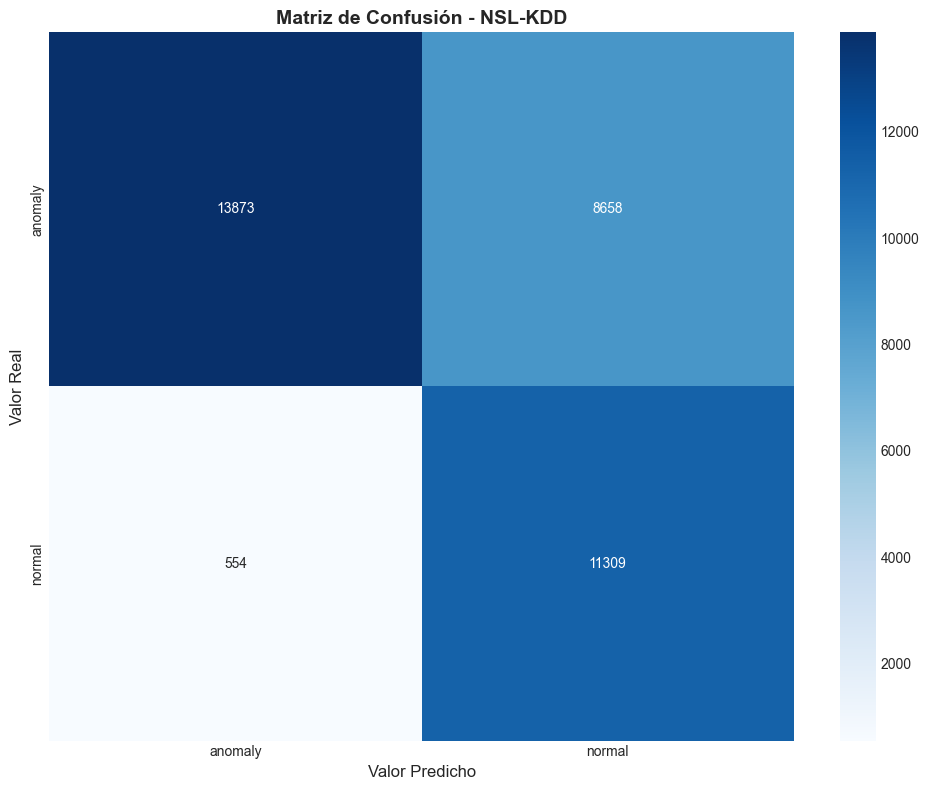

In [19]:
# ============================================================================
# MATRIZ DE CONFUSIÓN
# ============================================================================
print("=" * 80)
print("📊 MATRIZ DE CONFUSIÓN")
print("=" * 80)

cm = confusion_matrix(y_test, y_pred)

print(f"\n{cm}")

# Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matriz de Confusión - NSL-KDD', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Predicho', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================================
# REPORTE DE CLASIFICACIÓN COMPLETO
# ============================================================================
print("=" * 80)
print("📋 REPORTE DE CLASIFICACIÓN COMPLETO")
print("=" * 80)
print("\n" + classification_report(y_test, y_pred, target_names=class_names))

📋 REPORTE DE CLASIFICACIÓN COMPLETO

              precision    recall  f1-score   support

     anomaly       0.96      0.62      0.75     22531
      normal       0.57      0.95      0.71     11863

    accuracy                           0.73     34394
   macro avg       0.76      0.78      0.73     34394
weighted avg       0.83      0.73      0.74     34394



## 📝 8. Conclusiones

En este notebook hemos:
1. ✅ Cargado y explorado el dataset NSL-KDD para detección de intrusiones
2. ✅ Preprocesado los datos (codificación de variables categóricas y target)
3. ✅ Entrenado un modelo Proactive Forest
4. ✅ Evaluado el modelo con múltiples métricas de clasificación

### Resultados Clave:
- **Accuracy**: {report.accuracy:.2%}
- **F1-Score Macro**: {report.macro_f1:.2%}
- **Número de árboles**: {len(trees)}

El modelo Proactive Forest ha demostrado su capacidad para detectar intrusiones en redes.